# Two-Fold Periodic Functions

This notebook contains descriptions and examples for each of the functions relating to the two-fold periodic plot. These functions were created for application to a 3D electron azimuthal scattering dataset, but could be applied generically elsewhere.

In [1]:
# Required imports for the functions below
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# Importing the correct section of the repo
import ACPP_Bunjy.tfp as tfp

## Periodic Function

The work of this section is based around the first simple function which defines a two-fold periodic function of the form:

\begin{equation}
    y=A\times sin(x+B) + C\times sin(2x+D) + E
\end{equation}

The main experimental goal of the project is to establish good fitting of this function to an electron lattice dataset, With the axes of fitting for the function being the degrees of rotation of the lattice and the intensity measured at each. This fit is performed across a 2D pixel scan array and the found parameters can then be plotted respective to their pixels and examined as will be shown later. The first function here takes an input x-array and five parameter values A, B, C, D, and E, and returns an array of y values from the function. Note that the function has been designed to operate with x in units of degrees, not radians.

In [2]:
tfp.periodic([1,25,60,180],2,3,4,5,6)

array([ 6.62699032, 10.2155513 , 11.05862123,  6.24395106])

## Periodic Fitting

The following function, similarly to the progression of the weeks 1-3 example notebook, then applies Scipy curve fitting to the periodic function. This function works one dimensionally and is applied generally in an iterative process later. Below are listed the inputs and outputs of the function.

    Parameters
    ----------
    current_data: array-like
        Intensity of y-values for the data being fitted to.
    params_guess: list or array
        Array of initial estimate parameters for function values a-e.
    bounds: list or array
        Paired arrays defining the lower and upper bounds of possible parameters respectively.

    Returns
    -------
    params: numpy.ndarray
        Found parameters from curve fitting.
    errors: numpy.ndarray
        Associated parameters on each parameter.
    r_squared: float
        R² value associated with the fitted curve.

Important to note that choosing appropriate params_guess values can greatly increase the speed of the function, and that the bounds values should be set to have physical significance. Importantly, the amplitude and offset values A, C, E can be some positive float value, while the phase params B and D should be angularly constrained. Examples of these can be seen applied below.

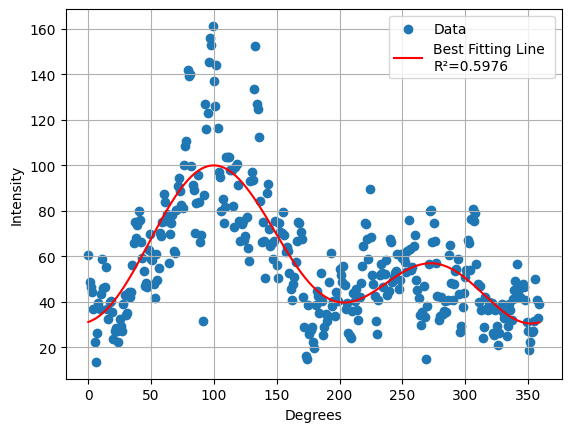

In [3]:
# Importing example lattice dataset
current_directory = os.getcwd()
example_data = np.load(current_directory+'/binned_diff_20210421_160712_PT1D.npy')

# Cropping dataset to examine a single pixel and defining an x array and parameter bounds
ex1d_crop = example_data[10,0,:]
deg = np.arange(0,len(ex1d_crop), 1)
params_guess = [0,0,0,0,0]
bounds = (
    [0,-180,0,-180,0],
    [np.inf,180,np.inf,180,np.inf]
)

# Running the fitting function
perfit = tfp.periodic_fitter(ex1d_crop, params_guess, bounds=bounds)

# Plotting results
plt.scatter(deg, ex1d_crop, label='Data')
plt.plot(deg, tfp.periodic(deg, *perfit[0]), color='red', label='Best Fitting Line \nR\u00B2={:.4g}'.format(perfit[2]))
plt.legend()
plt.xlabel('Degrees')
plt.ylabel('Intensity')
plt.grid()

## Iterative Periodic Fitting 

The perfit_iterate function is the primary result of this subsection of the project, taking the singular case fitting function from above and applying it to the complete 3D dataset. The input and output requirements of the function are shown below:

    Parameters
    ----------
    inp_array: array-like
        3D data array for curve fitting to the third array dimension.
    params_guess: list or array
        Array of initial estimate parameters for function values a-e.
    bounds: list or array
        Paired arrays defining the upper and lower bounds of possible parameters.
    iterative_fitting: bool, optional
        Argument toggle for implementing the iterative parameter guessing
        by using the parameter set found for the previous point in the iteration.
        
    Returns
    -------
    params_array: array
        Stacked array of fitted parameters 
    errors_array: array
        Stacked array of errors associated to found parameters.
    r2_array: array
        List of R² values.

The bounds argument should be physically constrained as before, and the params_guess selected carefully. The function has an option to apply iterative fitting, where in each iteration, the parameters calculated for the previous iteration are used as the starting point. In patterned data such as the electron lattice, where changes in parameter value between pixels follow a trend and occur gradually, application of this process can greatly improve performance of the function and speed up calculation time. In the instance of it being applied, the selection of the params_guess parameter is made less important as this is then only used for calculation of the first data point. The function will in general apply the iterative fitting as a default, but this can be toggled off for more sporadic datasets.

A progress bar has also been implemented in the function to show the progress of fitting to the dataset, helpful when running the function on very large datasets which take some time.

In [4]:
# Running the perfit_iterate function without iterative_fitting and a poorly selected initial parameter guess
example_noif = tfp.perfit_iterate(example_data, [0,0,0,0,0], bounds=bounds, iterative_fitting=False)

Fitting periodic functions: 100%|██████████| 1225/1225 [00:52<00:00, 23.33it/s]


In [5]:
# Running the perfit_iterate function with iterative_fitting applied
example_if = tfp.perfit_iterate(example_data, [0,0,0,0,0], bounds=bounds)

Fitting periodic functions: 100%|██████████| 1225/1225 [00:06<00:00, 181.69it/s]


The comparative performance of the function improves greatly with the application of iterative fitting. Between these two small example datasets, There is a reduction in time of processing from 49 seconds to 6 seconds. The iterative fitting would then linearly improve fitting time with larger datasets.

## Parameter Plotting

The final function of this section is a simple function to streamline plotting of the results of the perfit_iterate function. It displays a plt.imshow colourmap of each parameter corresponding to the pixel it was calculated for. The function was designed to create two plots for raw and clean values, which becomes useful when appling the fitting to raw and clean dataset pairs produced by functions in the decomposition section. It has an option to choose the title of the plots, and a toggle for residual plots to see differences between raw and cleaned data. The function takes inputs as follows:

    Parameters
    ----------
    raw_pdata: numpy.nparray
        Raw data output array from the perfit function, either params_array or errors_array.
    clean_pdata: numpy.nparray
        Clean data output array from the perfit function, either params_array or errors_array.
    name: str
        Name of the value being plotted, typically 'Parameter' or 'Error'.
    residuals: bool, optional
        Optional toggle to plot the residual difference of each plot pair in the subplot.
    cmap: str, optional
        Colourmap to use for imshow function, viridis as default.
        Options for colours: https://matplotlib.org/stable/gallery/color/colormap_reference.html

Below is the perfit dataset plotted twice as an example, however plots more typical of this function's use can be seen in the Compare_examples notebook, comparing the raw and clean data. The residual plots here are uniform at a value of zero, as would be expected for plotting the same data twice. The colourmap of each parameter however shows periodicity matching that of the lattice. This function can additionally be used to plot the error values of each parameter in each way to visualise reductions in errors after decomposition cleaning. Finally, the colourmap for imshow can be changed with the cmap argument, using the default viridis as a default. for a full list of options, see: https://matplotlib.org/stable/gallery/color/colormap_reference.html

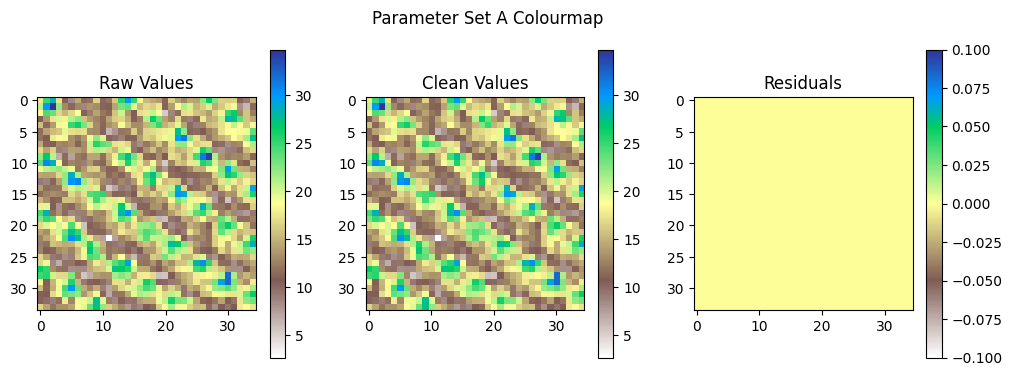

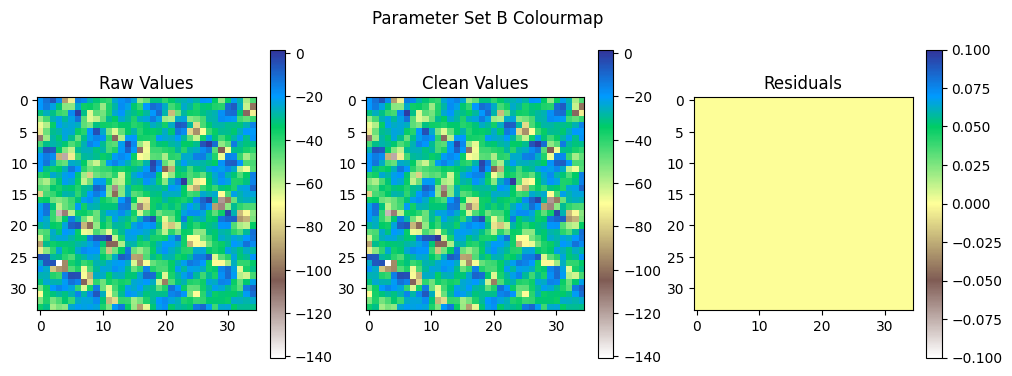

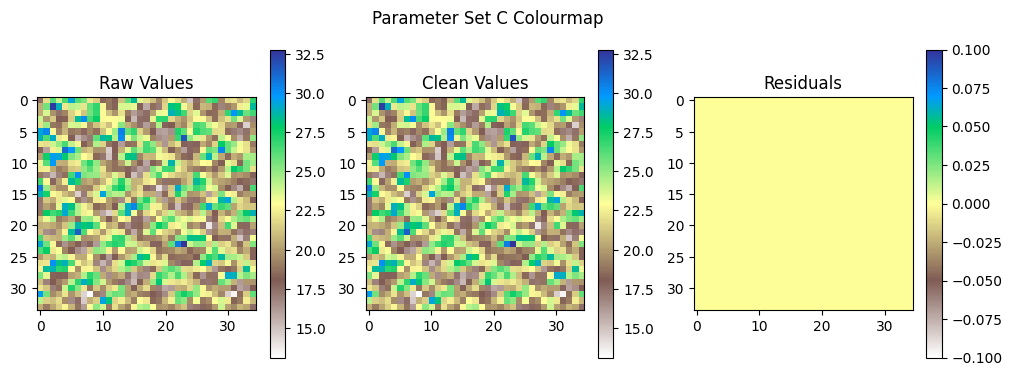

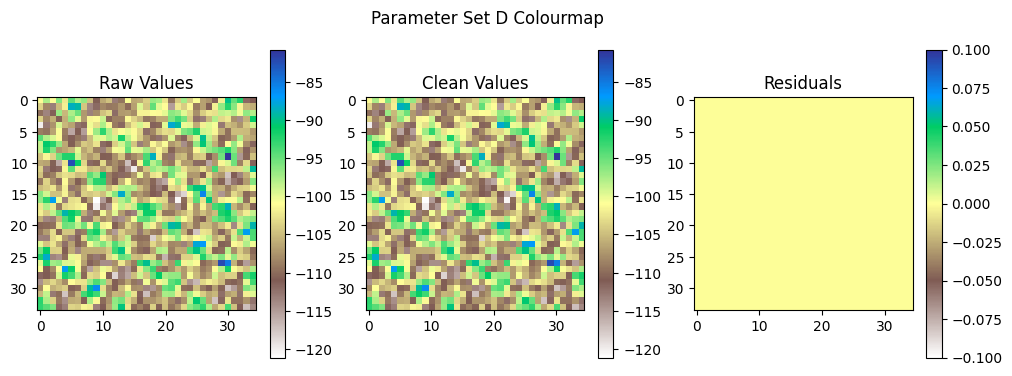

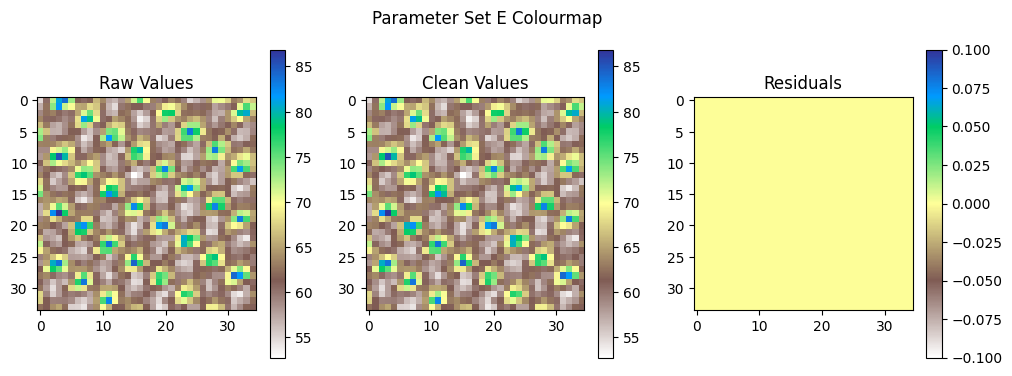

In [7]:
# PLotting the perfit dataset twice as an example
tfp.param_plotting(example_if[0][1:,...], example_if[0][1:,...], 'Parameter', residuals=True, cmap="terrain_r")